In [1]:
import pandas as pd
import joblib
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

In [2]:
df = pd.read_csv("../datasets/clean_190k_dataset.csv")

print("Dataset Loaded Successfully!")
print("Dataset Shape:", df.shape)

Dataset Loaded Successfully!
Dataset Shape: (189647, 378)


In [3]:
X = df.drop("diseases", axis=1)
y = df["diseases"]

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (189647, 377)
Target Shape: (189647,)


In [4]:
label_encoder = joblib.load("../models/label_encoder.pkl")

y_encoded = label_encoder.transform(y)

print("Label Encoder Loaded Successfully!")
print("Total Disease Classes:", len(label_encoder.classes_))

Label Encoder Loaded Successfully!
Total Disease Classes: 773


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42
)

print("Training Set:", X_train.shape)
print("Testing Set:", X_test.shape)

Training Set: (151717, 377)
Testing Set: (37930, 377)


In [6]:
dt_model = joblib.load("../models/decision_tree_model.pkl")
rf_model = joblib.load("../models/random_forest_model.pkl")

print("Both models loaded successfully!")

Both models loaded successfully!


In [7]:
dt_pred = dt_model.predict(X_test)
rf_pred = rf_model.predict(X_test)

print("Predictions completed!")

Predictions completed!


In [8]:
dt_accuracy = accuracy_score(y_test, dt_pred)
dt_precision = precision_score(y_test, dt_pred, average="weighted", zero_division=0)
dt_recall = recall_score(y_test, dt_pred, average="weighted", zero_division=0)
dt_f1 = f1_score(y_test, dt_pred, average="weighted", zero_division=0)

rf_accuracy = accuracy_score(y_test, rf_pred)
rf_precision = precision_score(y_test, rf_pred, average="weighted", zero_division=0)
rf_recall = recall_score(y_test, rf_pred, average="weighted", zero_division=0)
rf_f1 = f1_score(y_test, rf_pred, average="weighted", zero_division=0)

In [9]:
comparison = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-Score"],
    "Decision Tree": [
        dt_accuracy,
        dt_precision,
        dt_recall,
        dt_f1
    ],
    "Random Forest": [
        rf_accuracy,
        rf_precision,
        rf_recall,
        rf_f1
    ]
})

comparison

,Metric,Decision Tree,Random Forest
0,Accuracy,0.754891,0.016030
1,Precision,0.760003,0.012480
2,Recall,0.754891,0.016030
3,F1-Score,0.754279,0.013569


In [10]:
print("=" * 60)
print("MODEL PERFORMANCE COMPARISON")
print("=" * 60)

display(comparison)

MODEL PERFORMANCE COMPARISON


,Metric,Decision Tree,Random Forest
0,Accuracy,0.754891,0.016030
1,Precision,0.760003,0.012480
2,Recall,0.754891,0.016030
3,F1-Score,0.754279,0.013569


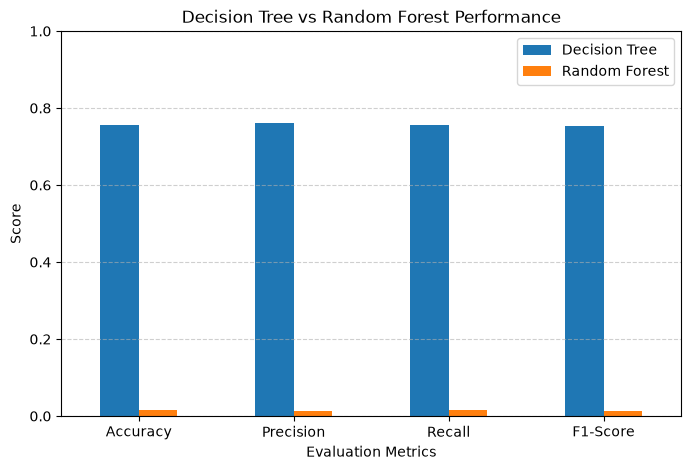

In [11]:
comparison.set_index("Metric").plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Decision Tree vs Random Forest Performance")
plt.xlabel("Evaluation Metrics")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.6)

plt.show()

In [12]:
print("=" * 60)
print("DECISION TREE CLASSIFICATION REPORT")
print("=" * 60)

print(classification_report(
    y_test,
    dt_pred,
    zero_division=0
))

DECISION TREE CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.27      0.60      0.38         5
           1       0.87      0.92      0.89        49
           2       0.39      0.66      0.49        29
           3       1.00      1.00      1.00         1
           4       0.41      0.76      0.54        25
           5       0.25      0.50      0.33         2
           6       0.00      0.00      0.00         1
           7       0.00      0.00      0.00         4
           8       0.46      0.63      0.53        82
           9       0.49      0.68      0.57       155
          10       0.83      0.91      0.87       238
          11       0.62      0.67      0.65       247
          12       0.51      0.64      0.57       166
          13       0.00      0.00      0.00         0
          14       0.11      0.23      0.15        30
          15       0.86      0.90      0.88       168
          16       0.57      0.60      0.59  

In [13]:
print("=" * 60)
print("RANDOM FOREST CLASSIFICATION REPORT")
print("=" * 60)

print(classification_report(
    y_test,
    rf_pred,
    zero_division=0
))

RANDOM FOREST CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         5
           1       1.00      0.57      0.73        49
           2       0.00      0.00      0.00        29
           3       0.00      0.00      0.00         1
           4       0.50      0.12      0.19        25
           5       0.00      0.00      0.00         2
           6       0.00      0.00      0.00         1
           7       0.00      0.00      0.00         4
           8       0.00      0.00      0.00        82
           9       0.00      0.00      0.00       155
          10       0.52      0.96      0.67       238
          11       0.65      0.89      0.75       247
          12       0.69      0.70      0.70       166
          14       0.00      0.00      0.00        30
          15       0.00      0.00      0.00       168
          16       0.00      0.00      0.00       108
          17       0.00      0.00      0.00  

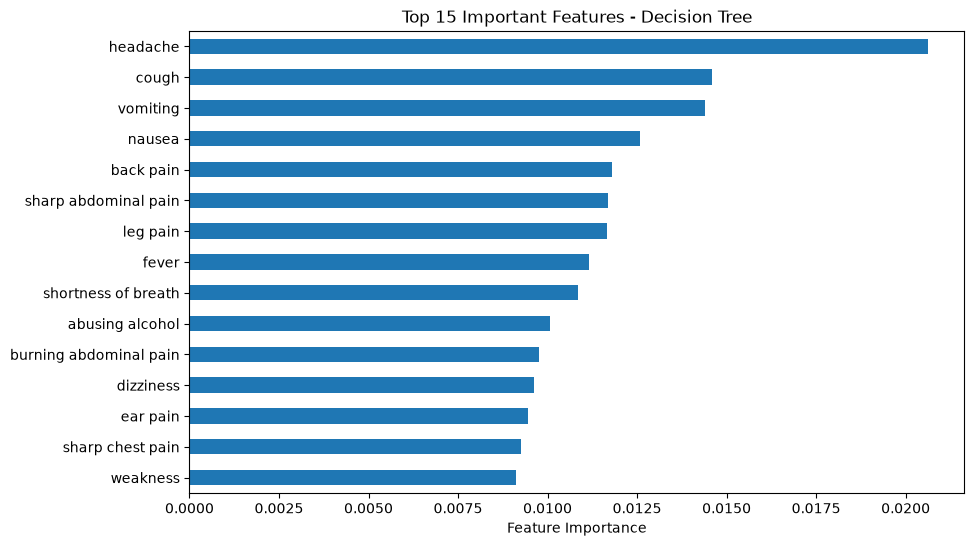

In [14]:
importance_dt = pd.Series(
    dt_model.feature_importances_,
    index=X.columns
)

top15_dt = importance_dt.sort_values(
    ascending=False
).head(15)

plt.figure(figsize=(10,6))

top15_dt.plot(kind="barh")

plt.title("Top 15 Important Features - Decision Tree")
plt.xlabel("Feature Importance")

plt.gca().invert_yaxis()

plt.show()

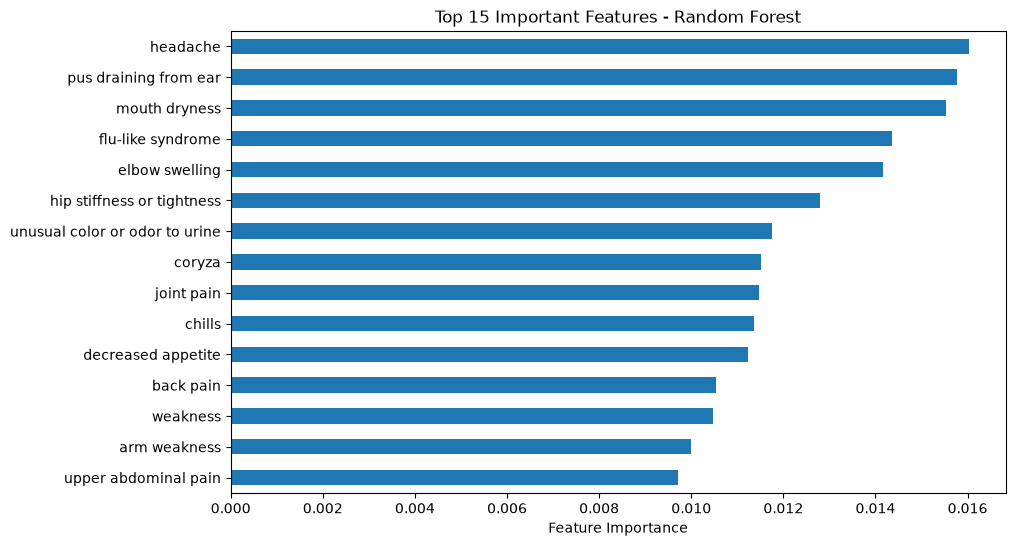

In [15]:
importance_rf = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
)

top15_rf = importance_rf.sort_values(
    ascending=False
).head(15)

plt.figure(figsize=(10,6))

top15_rf.plot(kind="barh")

plt.title("Top 15 Important Features - Random Forest")
plt.xlabel("Feature Importance")

plt.gca().invert_yaxis()

plt.show()

In [16]:
comparison.to_csv("../reports/model_comparison.csv", index=False)

print("Comparison table saved successfully!")

Comparison table saved successfully!


# Model Comparison Summary

This notebook compares the Decision Tree and Random Forest classifiers using
weighted evaluation metrics including Accuracy, Precision, Recall, and F1-Score.

Feature importance analysis was also performed to identify the most influential
symptoms used by each model.

A confusion matrix was not included because the dataset contains 773 disease
classes, resulting in a 773 × 773 matrix that is difficult to interpret.
Therefore, weighted performance metrics were used for comparison.

# Conclusion

The Decision Tree model achieved higher Accuracy, Precision, Recall, and F1-Score than the Random Forest model on the evaluation dataset.

The Random Forest model was trained using a sampled dataset due to hardware limitations during training. Therefore, its performance metrics should be interpreted in the context of this implementation constraint. For detailed information, refer to the Random Forest Training notebook.